In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import t

In [11]:
np.random.seed(1)

#### Independent t-Test

Control Mean: 99.74485151992349
Treatment Mean: 106.46680552159047


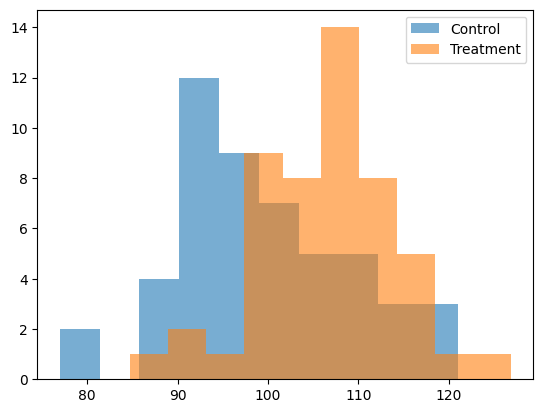

In [12]:
# Creating datasets.

control = np.random.normal(loc=100, scale=10, size=50)

treatment = np.random.normal(loc=105, scale=10, size=50)

# Examine descriptive statistics.

print("Control Mean:",
      np.mean(control))

print("Treatment Mean:",
      np.mean(treatment))

# Visualizing.

plt.hist(control, alpha=0.6)

plt.hist(treatment, alpha=0.6)

plt.legend([
    "Control",
    "Treatment"
])

plt.show()

In [13]:
# Runing independent samples t-test.

result = stats.ttest_ind(treatment, control)

print(result)

TtestResult(statistic=np.float64(3.7767905078225144), pvalue=np.float64(0.00027258969735696276), df=np.float64(98.0))


In [14]:
# Computing Cohen's d.

mean_diff = (
    np.mean(treatment)
    -
    np.mean(control)
)

pooled_sd = np.sqrt(
    (
        np.var(control, ddof=1)
        +
        np.var(treatment, ddof=1)
    ) / 2
)

d = mean_diff / pooled_sd

print("Cohen's d:", d)

Cohen's d: 0.7553581015645029


In [16]:
# Calculating confidence interval for mean difference.

# Mean difference.

mean_diff = (np.mean(treatment) - np.mean(control))

# Standard error.

se_diff = np.sqrt(
    np.var(control, ddof=1)/len(control)
    +
    np.var(treatment, ddof=1)/len(treatment)
)

# 95% CI.

df = len(control) + len(treatment) - 2

critical = t.ppf(0.975, df)

lower = mean_diff - critical*se_diff
upper = mean_diff + critical*se_diff

print("CI:", lower, upper)

CI: 3.1899871320769675 10.253920871257005


#### APA style reporting of independent t-test.

Control Mean = 99.74

Treatment Mean = 106.46

t = 3.77

df = 98.0

p < .001

d = 0.755

#### Paired t-Test

Difference befor and after:
 [1.87235327 3.24996407 5.38170035 8.68580027 5.24300078 5.84449902
 5.06611027 5.70875088 0.53411993 5.3237084  4.25368403 4.77270208
 6.96934622 2.27728744 4.66196789 3.81055247 6.66920802 8.1390826
 1.17829895 7.34364172]
Difference mean: 4.849288933376881


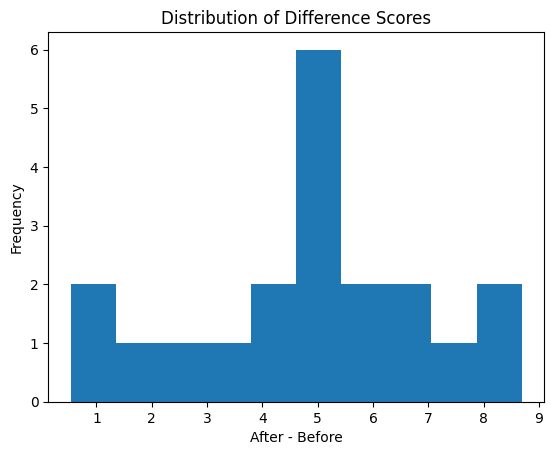

TtestResult(statistic=np.float64(9.769980587911652), pvalue=np.float64(7.646388837593135e-09), df=np.int64(19))


In [22]:
# Simulating a pre-post experiment.

before = np.random.normal(loc=100, scale=10, size=20)

after = before + np.random.normal(loc=5, scale=4, size=20)

# Computing difference scores.

difference = after - before

print("Difference befor and after:\n", difference)

# Computing mean difference.

print("Difference mean:", difference.mean())

# Visualizing the differences.

plt.hist(difference, bins=10)

plt.title("Distribution of Difference Scores")
plt.xlabel("After - Before")
plt.ylabel("Frequency")

plt.show()

# Computing the paired t-test.

result = stats.ttest_rel(after, before)

print(result)

In [24]:
# Computing descriptive statistics.

print("Mean before:", np.mean(before))
print("Mean after:", np.mean(after))
print("SD before:", np.std(before, ddof=1))
print("SD after:", np.std(after, ddof=1))

Mean before: 101.82136359190085
Mean after: 106.6706525252777
SD before: 9.249729999053141
SD after: 9.878478472138939


In [25]:
# Computing confidence interval.

n = len(difference)

# Mean difference.

mean_diff = np.mean(difference)

# Standard deviation of differences.

sd_diff = np.std(
    difference,
    ddof=1
)

# Standard error.

se_diff = sd_diff / np.sqrt(n)

# Critical value.

critical = t.ppf(0.975, df=n-1)

# Confidence interval.

lower = mean_diff - critical*se_diff
upper = mean_diff + critical*se_diff

print("CI:", lower, upper)

CI: 3.8104252127168863 5.888152654036876


In [28]:
# Computing effect size.

d = mean_diff / sd_diff

print("d:", d)

d: 2.1846340733423815


#### APA style reporting of paired t-test.

Before Mean = 101.82

After Mean = 106.67

t(19) = 9.77

df = 19

p < .001

d = 2.18